
###  Assignment 1
##### Development Environment setup
![alt text](env_screenshot.png "ENV Screenshot")



Assignment  2
Simulation of Multivariate Normal Distribution

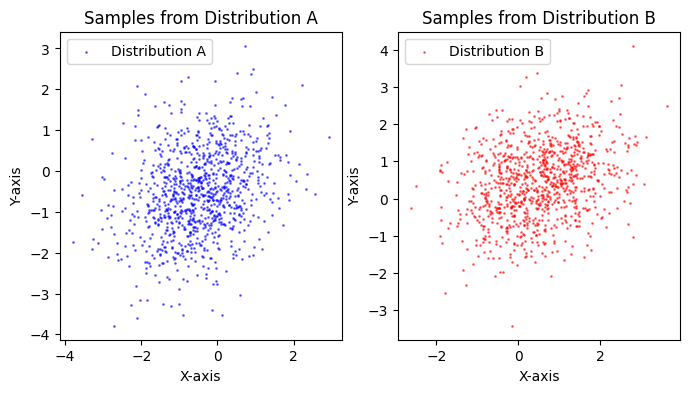

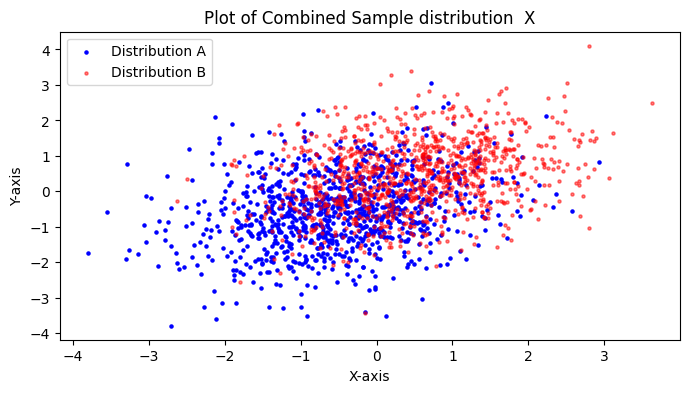

In [7]:
import torch
import matplotlib.pyplot as plt

# Using a NVIDIA GPU - hence using cuda
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


# First Bivariate Normal distrubution parameters - according to the assignemnt
# we basically initialize a  1 D tensor , which contains the values for mean
# additionally the device = device serves as a way to run this using GPU
meanA = torch.tensor([-0.5, -0.5], device=device)
covariancMatrixA = torch.tensor([[1.0, 0.25], [0.25, 1.0]], device=device)
distributionA = torch.distributions.MultivariateNormal(meanA, covariancMatrixA)

# Now we are adding the parameters for the second one
meanB= torch.tensor([0.5, 0.5], device=device)
covariancMatrixB = covariancMatrixA # since the covariance in B is same as
distributionB = torch.distributions.MultivariateNormal(meanB, covariancMatrixB)

# Here we get the samples for both distributions
# we need a 1000 samples for both according to the question
samplesOfA = distributionA.sample((1000,))
samplesOfB = distributionB.sample((1000,))


# Scatter plot for samples from Distribution A


plt.figure(figsize=(8, 4))

samplesA_np = samplesOfA.cpu().numpy()
plt.subplot(1, 2, 1)
x_axis_of_A = samplesA_np[:, 0]
y_axis_of_A= samplesA_np[:, 1]
sizeA = 1
alphaA = 0.5 # transparency
plt.scatter(samplesA_np[:, 0], samplesA_np[:, 1], c='blue', s=sizeA, alpha=alphaA, label='Distribution A')
plt.title('Samples from Distribution A')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.legend()


samplesB_np = samplesOfB.cpu().numpy()
plt.subplot(1, 2, 2)
x_axis_of_B = samplesB_np[:, 0]
y_axis_of_B = samplesB_np[:, 1]
sizeB = 1
alphaB = 0.5 # transparency
plt.scatter(x_axis_of_B, y_axis_of_B , c='red', s=sizeB, alpha=alphaB, label='Distribution B')
plt.title('Samples from Distribution B')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.legend()


# now we will combine both

# Here we combine both into a single tensor X
X = torch.cat((samplesOfA, samplesOfB), dim=0)
labels = torch.cat((torch.zeros(1000, dtype=torch.long), torch.ones(1000, dtype=torch.long)), dim=0)

# Move combined samples to CPU for plotting
Xcpu = X.cpu().numpy()
labelscpu = labels.cpu().numpy()

# Plotting
plt.figure(figsize=(8, 4))

# Scatter plot of samples from Distribution 1
plt.scatter(Xcpu[labelscpu == 0, 0], Xcpu[labelscpu == 0, 1], c='blue', s=5, label='Distribution A', alpha=1)

# Scatter plot of samples from Distribution 2
plt.scatter(Xcpu[labelscpu == 1, 0], Xcpu[labelscpu == 1, 1], c='red', s=5, label='Distribution B', alpha=0.5)

plt.title('Plot of Combined Sample distribution  X')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.legend()
plt.show()




Assignment 3
K means

Assignment 3
PCA